<h3 align="center"> Credit Card Fraud Detector </h3>


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time
from collections import Counter
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 28
np.random.seed(RANDOM_STATE)


In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<h3> How does the Data look like? </h3>
<ul>
<li> (99.83%) of the data are non-fraud, while <b>Fraud</b> transactions occurs (017%) of the time in the dataframe. </li>
<li> <b>Scaling:</b> All the V features are scaled. The time and amount features are to be scaled.</li>
</ul>

In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
# Good No Null Values!
df.isnull().sum().max()

np.int64(0)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

<ul>
<li> (99.83%) of the data are non-fraud, while <b>Fraud</b> transactions occurs (017%) of the time in the dataframe. </li>
</ul>

In [6]:
# The classes are heavily skewed 
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


**Distributions:** By seeing the distributions we can have an idea how skewed are these features, we can also see further distributions of the other features. There are techniques that can help the distributions be less skewed which will be implemented in this notebook in the future.

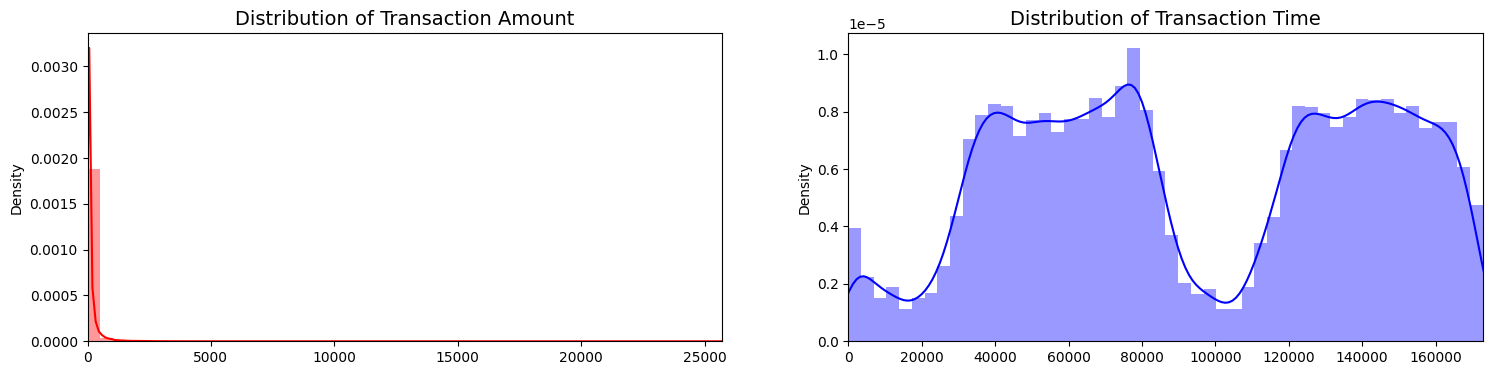

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])



plt.show()

Splitting data using stratified to keep the class ratio (fraud and non-fraud) same in the train and test

In [8]:
X = df.drop('Class', axis=1)
y = df['Class']

# stratified split 
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:", Counter(y_train))
print("Test class distribution:", Counter(y_test))

Train shape: (227845, 30) Test shape: (56962, 30)
Train class distribution: Counter({0: 227451, 1: 394})
Test class distribution: Counter({0: 56864, 1: 98})


Scaling Amount and Time features

**Note** Never fit_transform on the whole dataset, that leaks information from test and gives overly optimistic performance.

In [52]:
# Since most of the data has already been scaled we should scale the columns that are left to scale (Amount and Time)
from sklearn.preprocessing import RobustScaler
import joblib
# RobustScaler is less prone to outliers.

scaler = RobustScaler()

# do scaler fit_transform on the TRAINING data and only transform scaler on the TEST data
X_train_amount_time = scaler.fit_transform(X_train[['Amount','Time']])
X_test_amount_time = scaler.transform(X_test[['Amount','Time']])

# replace raw columns with scaled versions in copies of X_train/X_test
X_train_fin = X_train.copy()
X_test_fin = X_test.copy()

X_train_fin['Amount_Scaled'] = X_train_amount_time[:,0] 
X_train_fin['Time_Scaled']   = X_train_amount_time[:,1]

X_test_fin['Amount_Scaled']  = X_test_amount_time[:,0]
X_test_fin['Time_Scaled']    = X_test_amount_time[:,1]

# drop old amount and time columns
X_train_fin = X_train_fin.drop(['Amount','Time'], axis=1)
X_test_fin  = X_test_fin.drop(['Amount','Time'], axis=1)

print("After scaling, feature count:", X_train_fin.shape[1])

#save RobustScaler to use it further in FastAPI
joblib.dump(scaler, "amount_time_scaler.pkl")
print("✅ Scaler saved to amount_time_scaler.pkl")


After scaling, feature count: 30
✅ Scaler saved to amount_time_scaler.pkl


### SMOTE Technique (Over-Sampling):
<b>SMOTE</b> stands for Synthetic Minority Over-sampling Technique. SMOTE creates new synthetic points in order to have an equal balance of the classes. This is another alternative for solving the "class imbalance problems". <br><br>

### Overfitting during Cross Validation:  
Undersampling or oversampling should not be done before cross validation. This is to avoid data-leakage problem, i.e avoid showing the validation set already during cross validation. 
### The Wrong Way:
<img src="https://www.marcoaltini.com/uploads/1/3/2/3/13234002/2639934.jpg?401"><br>

The minority class ("Fraud) in our case is oversampled using SMOTE before cross validating. We have a certain influence on the "validation set" of the cross validation process. Remember how cross validation works, let's assume we are splitting the data into 5 batches, 4/5 of the dataset will be the training set while 1/5 will be the validation set. The test set should not be touched! For that reason, we have to do the creation of synthetic datapoints "during" cross-validation and not before, just like below: <br>

### The Right Way:
<img src="https://www.marcoaltini.com/uploads/1/3/2/3/13234002/9101820.jpg?372"> <br>
As you see above, SMOTE occurs "during" cross validation and not "prior" to the cross validation process. Synthetic data are created only for the training set without affecting the validation set.

XGBoost + SMOTE + CV Pipeline

Future work: XGBoost + SMOTE + RandomizedSearchCV Pipeline --> this requires computing time and power to find the best params for the GradientBoost 

In [13]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score
)


# 2. Initialize lists to store metrics for each fold
metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# 1. Setup the Stratified Cross-Validation
# This ensures each fold has the same percentage of fraud as the original data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Initialize the XGBoost Model
# We keep parameters slightly conservative to prevent overfitting with SMOTE
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 3. Create the Imbalanced-Learn Pipeline
# Order: Sampler (SMOTE) -> Classifier (XGBoost)
pipeline = ImbPipeline([
    ('smote', SMOTE(sampling_strategy='minority', random_state=42)),
    ('classifier', xgb_model)
])

# 5. The CV Loop
for i, (train_index, test_index) in enumerate(skf.split(X_train_fin, y_train)):
    # Use .iloc for safe indexing if X is a DataFrame
    X_train_fold, X_val_fold = X_train_fin.iloc[train_index], X_train_fin.iloc[test_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[test_index]
    
    # Fit the pipeline (SMOTE happens only on the training indices here)
    pipeline.fit(X_train_fold, y_train_fold)
    
    # Predict
    y_pred = pipeline.predict(X_val_fold)
    y_proba = pipeline.predict_proba(X_val_fold)[:, 1]

    # Calculate Metrics
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec = recall_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred)
    auc = roc_auc_score(y_val_fold, y_proba)

    # Store Metrics
    metrics['accuracy'].append(acc)
    metrics['precision'].append(prec)
    metrics['recall'].append(rec)
    metrics['f1'].append(f1)
    metrics['auc'].append(auc)
    
    print(f"Fold {i+1} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    

# 5. Print Final Averages
print("\n" + "="*30)
print("FINAL CROSS-VALIDATION RESULTS")
print("="*30)
for metric, scores in metrics.items():
    print(f"Average {metric.capitalize():<10}: {np.mean(scores):.4f}")
print("="*30)

Fold 1 | Prec: 0.7234 | Rec: 0.8718 | F1: 0.7907
Fold 2 | Prec: 0.7674 | Rec: 0.8354 | F1: 0.8000
Fold 3 | Prec: 0.7143 | Rec: 0.8861 | F1: 0.7910
Fold 4 | Prec: 0.7333 | Rec: 0.8354 | F1: 0.7811
Fold 5 | Prec: 0.7590 | Rec: 0.7975 | F1: 0.7778

FINAL CROSS-VALIDATION RESULTS
Average Accuracy  : 0.9992
Average Precision : 0.7395
Average Recall    : 0.8452
Average F1        : 0.7881
Average Auc       : 0.9783


SMOTE on full training data (X_train_fin and y_train)

In [15]:
# SMOTE Technique (OverSampling) After splitting train-test data and Cross Validating
# from this training data - Xsm_train, ysm_train The final XGBoost model is built

sm = SMOTE(sampling_strategy='minority', random_state=42)

# This will be the data were we are going to 
Xsm_train, ysm_train = sm.fit_resample(X_train_fin, y_train)

In [ ]:
# Final XGBoost model

final_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

# 3. Fit on the entire resampled training set
final_xgb.fit(Xsm_train, ysm_train)

# 4. SAVE THIS MODEL
import joblib
joblib.dump(final_xgb, 'final_xgboost_model.pkl')

['final_xgboost_model.pkl']

### XGB Model Prediction and EVALUATION

ROC-AUC score

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_xgb = final_xgb.predict(X_test_fin)
y_prob_xgb = final_xgb.predict_proba(X_test_fin)[:,1]


print(classification_report(y_test, y_pred_xgb))
print("ROC AUC (XGB):", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.83      0.75        98

    accuracy                           1.00     56962
   macro avg       0.85      0.91      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC (XGB): 0.9724855509170466


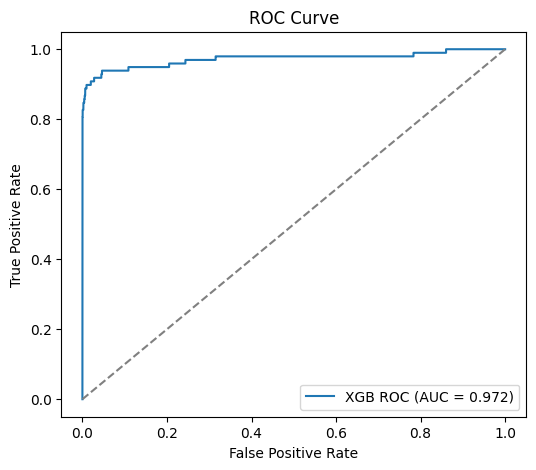

In [21]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"XGB ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("graphs/roc_curve.png", bbox_inches='tight')
plt.show()


### 📊 Precision-Recall Analysis

In this project, we are dealing with a **highly imbalanced dataset** (Frauds represent < 1% of total transactions). In such cases, standard metrics like Accuracy or the ROC Curve can be misleadingly optimistic.

#### 1. Key Metrics for Fraud Detection
* **Recall (Sensitivity):** "How many frauds did we catch?" High recall means we are identifying most of the actual fraudulent transactions.
* **Precision:** "How reliable are our alarms?" High precision means that when we flag a transaction as fraud, it is likely to be actual fraud, minimizing "false alarms" for legitimate customers.

#### 2. The Precision-Recall (PR) Curve
The **PR Curve** plots Precision vs. Recall across all possible classification thresholds. 


* **The Goal:** We want the curve to stay as close to the **top-right corner** (where both Precision and Recall = 1.0) as possible.
* **The Trade-off:** There is an inverse relationship between these two metrics. As we try to catch more fraud (increasing Recall), we inevitably become more "suspicious" and flag more honest transactions by mistake (decreasing Precision).

#### 3. PR vs. ROC: Why it matters here
While the **ROC Curve** considers both classes, it can be "deceived" by a large number of True Negatives (correctly identified normal transactions). 

The **PR Curve** is a much "tougher" and more honest assessment for imbalanced data because it focuses almost exclusively on the **Positive (Fraud) class**. It reveals exactly how much the model struggles to separate the Fraud (needle) from the Normal (haystack).

#### 4. Average Precision (AP)
The **Average Precision** score summarizes the PR curve into a single number representing the area under the curve. A higher AP score indicates a more robust model that can maintain high precision even as it successfully identifies more fraud.

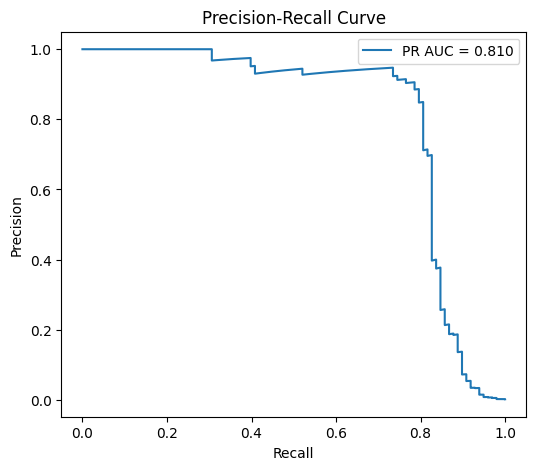

In [33]:
# Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig("graphs/precision_recall_curve.png", bbox_inches='tight')
plt.show()

From the Precision-Recall curve above we can conclude that though the XGBoost model is not perfect (score = 1), but it is still well-balanced (score = 0.810).

If we compromise the precision to 0.9 then recall is approximately 0.8. 
Precision = 0.90: means that out of all the transactions the model labeled as fraud, 90% were actually fraud, and 10% were false alarms (legitimate transactions).
Recall = 0.80: means the model successfully identifies 80% of all actual fraud cases.

If we consider catching all the Frauds (recall = 1), then the precision drops to ~0.8 (20% false alarms) which isn't fair for customers doing normal transactions in the real world scenario. So its important to find the right balance between the precision and recall.

Confusion Matrix

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

def constructConfusionMat(threshold):
    #Threshold is the strictness level (e.g., "Only flag this as fraud if the model is 50% sure").
    y_pred_default = (y_prob_xgb >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_default)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal","Fraud"])
    disp.plot(cmap='Greens')
    plt.title("Confusion Matrix @ threshold 0.5")
    plt.savefig("graphs/confusion_matrix_default.png", bbox_inches='tight')
    plt.show()


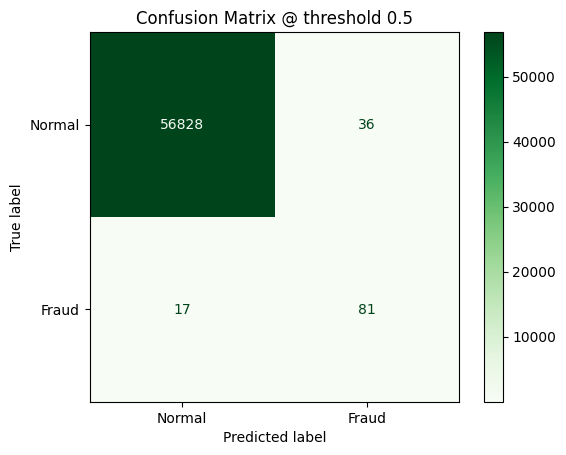

In [44]:
constructConfusionMat(0.5)

In fraud detection, the default classification threshold of **0.5** is rarely optimal. Because **SMOTE** is used to balance the training data, the model's output probabilities are calibrated for a 50/50 world. When applied to the real-world imbalanced test set, we must recalibrate our threshold to meet both statistical and business goals.

---

### Why use F1-Score to determine Threshold?

We use the **F1-Score** (the harmonic mean of Precision and Recall) to find a mathematically "fair" balance. Unlike a simple average, the harmonic mean "punishes" extreme values.
* **Robustness:** It prevents the model from favoring one metric at the extreme expense of the other.
* **Imbalance Handling:** F1-score ignores "True Negatives" (the millions of normal transactions) and focuses only on how well you handle the "Positive" (Fraud) class.

Best Threshold (F1): 0.9394
Highest F1 Score: 0.8415


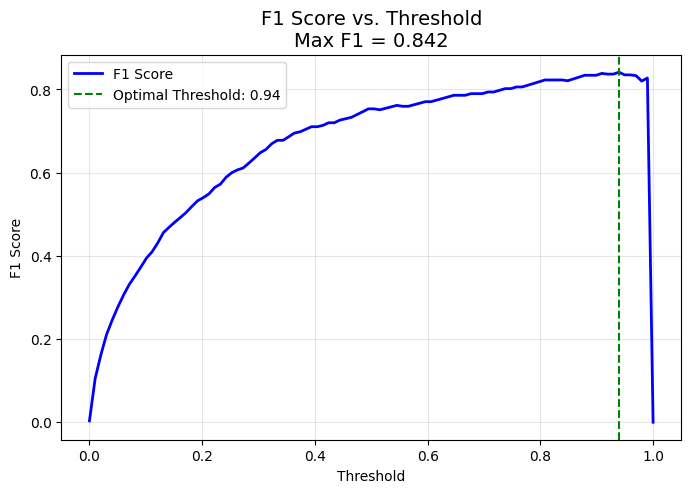

Optimal Threshold: 0.9394
Maximum F1-Score: 0.8415


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# 1. Define a range of thresholds from 0 to 1
thresholds = np.linspace(0, 1, 100)
f1_scores = []

# 2. Calculate F1 for each threshold
# Note: y_prob_xgb should be model's predicted probabilities for the positive class
for t in thresholds:
    y_pred = (y_prob_xgb >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

# 3. Identify the optimal point
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]
best_f1_score = f1_scores[best_f1_idx]

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, label='F1 Score', color='blue', lw=2)
plt.axvline(best_f1_threshold, color='green', linestyle='--', 
            label=f'Optimal Threshold: {best_f1_threshold:.2f}')

plt.title(f'F1 Score vs. Threshold\nMax F1 = {best_f1_score:.3f}', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Threshold: {best_f1_threshold:.4f}")
print(f"Maximum F1-Score: {best_f1_score:.4f}")

Confusion Matrix for Threshold = 0.94 (derived from best F1-score)

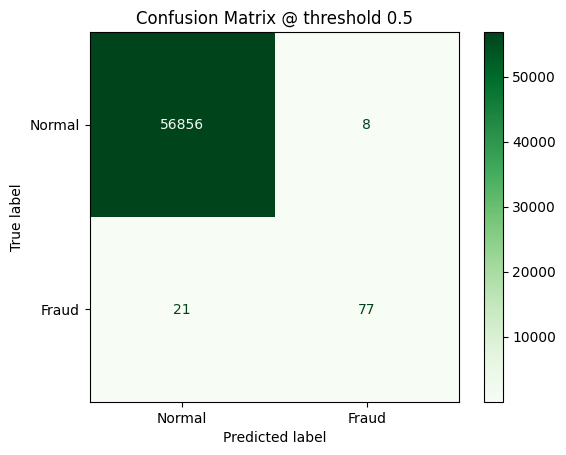

In [45]:
constructConfusionMat(0.94)

Cost Optimal Threshold

**The Problem with F1-Score:**
The F1-score is a statistical abstraction. It treats a $10,000 fraud loss and a $20 administrative "false alarm" as equal errors. In a banking environment, this is commercially unrealistic.

**The Solution: Cost-Optimal Selection**
The **Cost-Optimal** method aligns the model with the bank's business model.
* **Asymmetric Risk:** It recognizes that missing a fraud (False Negative) is significantly more expensive than a false alert (False Positive).
* **Financial Optimization:** By calculating the "Total Business Cost" (Admin Costs + Fraud Losses) at every threshold, we identify the exact point where the bank loses the least amount of money.
* **Business Justification:** It allows us to move from "How accurate is the model?" to "How much money does this model save?"

---

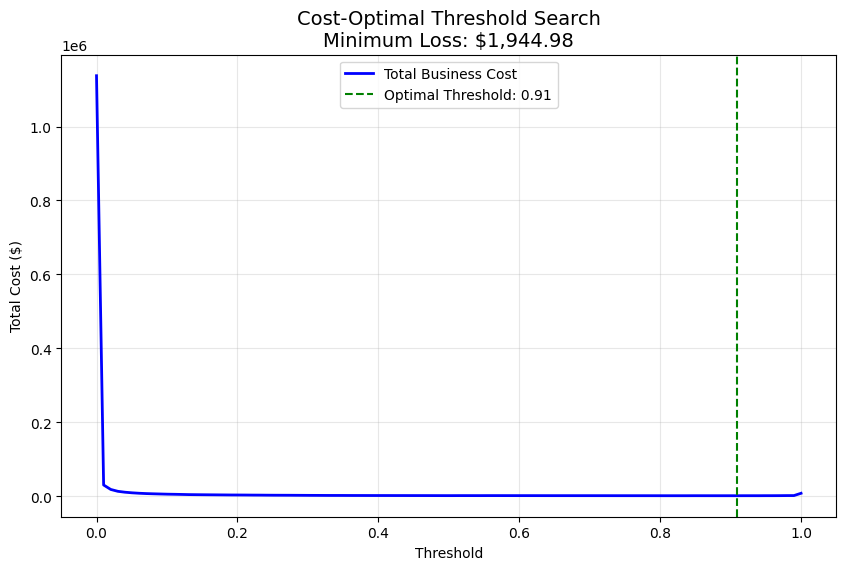

Minimum Cost Threshold: 0.9091


In [47]:

# 1. Define Business Costs
# Cost of a False Positive (e.g., $20 for admin/support time)
cost_fp = 20 

# To calculate cost of a False Negative (the stolen money) the average transaction amount from the data is considered
# We can also consider median of the transaction amount in the data
avg_fraud_loss = X_test['Amount'].mean() if 'Amount' in X_test.columns else 100

thresholds = np.linspace(0, 1, 100)
total_costs = []

# 2. Loop through thresholds to calculate financial impact
for t in thresholds:
    y_pred = (y_prob_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Financial Formula: (False Alarms * $20) + (Missed Frauds * Fraud Value)
    cost = (fp * cost_fp) + (fn * avg_fraud_loss)
    total_costs.append(cost)

# 3. Find the minimum cost point
best_cost_idx = np.argmin(total_costs)
optimal_cost_threshold = thresholds[best_cost_idx]
min_cost = total_costs[best_cost_idx]

# 4. Plot the Cost Curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, total_costs, color='blue', lw=2, label='Total Business Cost')
plt.axvline(optimal_cost_threshold, color='green', linestyle='--', 
            label=f'Optimal Threshold: {optimal_cost_threshold:.2f}')

plt.title(f'Cost-Optimal Threshold Search\nMinimum Loss: ${min_cost:,.2f}', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Minimum Cost Threshold: {optimal_cost_threshold:.4f}")

Conclusion:

Both optimization methods suggest an unusually high decision threshold (above 0.90). This indicates that the XGBoost model has high discriminative power, clearly separating fraud from legitimate transactions with high confidence. While the F1-optimal threshold (0.94) maximizes the statistical balance, the Cost-optimal threshold (0.91) provides a slightly more inclusive safety margin, minimizing total financial loss to $1,944.98. Given the high cost of missed fraud transactions, the 0.91 threshold is choosen.

In [48]:
# Apply the Cost-Optimal Threshold
final_threshold = 0.91
y_pred_final = (y_prob_xgb >= final_threshold).astype(int)

# Final Evaluation
from sklearn.metrics import classification_report
print(f"--- Final Evaluation at Threshold {final_threshold} ---")
print(classification_report(y_test, y_pred_final))

--- Final Evaluation at Threshold 0.91 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.94      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



Observations


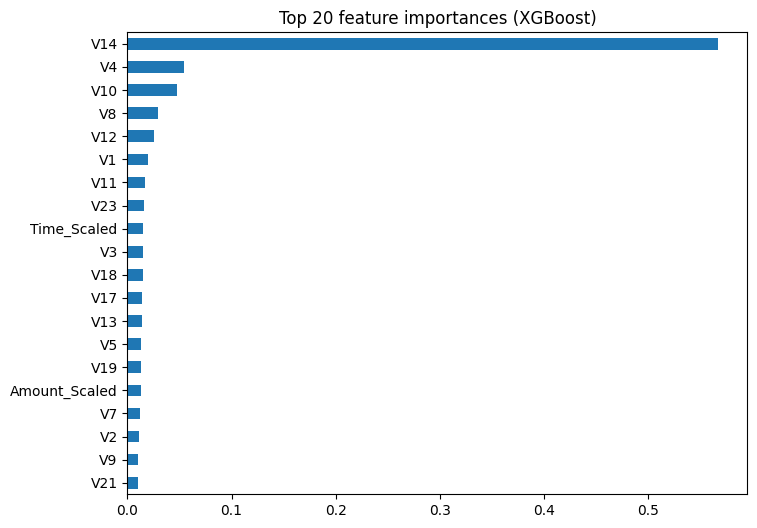

In [51]:
feat_imp = pd.Series(final_xgb.feature_importances_, index=X_test_fin.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 feature importances (XGBoost)")
plt.savefig("graphs/feature_importances.png", bbox_inches='tight')
plt.show()